# Business Sales Performance Analytics
## Executive Exploratory Data Analysis & Strategic Intelligence
**Role:** Senior Data Analyst & Python BI Consultant  
**Core Objective:** Conduct a comprehensive, end-to-end exploratory analysis of the raw historical sales transactions to isolate seasonal growth patterns, identify profit leakage, analyze catalog performance, and establish key corporate metrics before constructing the executive dashboard.

### 1. Environmental Setup & Dependency Ingestion
First, we ingest the critical python libraries representing the standard corporate data science stack:
* **Pandas:** Vectorized data manipulation.
* **NumPy:** Mathematical calculations and array structuring.
* **Matplotlib & Seaborn:** Statistical chart plotting and styling.
* **Scipy (Z-Score):** Outlier validation testing.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Apply standard visualization parameters for a clean corporate appearance
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

print("[INFO] Analytical libraries successfully loaded.")

[INFO] Analytical libraries successfully loaded.


### 2. Transactional Data Ingestion
We load the raw transactional data from the raw directory. The standard encoding CP1252 or Latin-1 is specified to handle potential encoding characters gracefully.

In [2]:
# Define paths
raw_data_path = "../data/raw/superstore.csv"

# Ingest and display metadata
df_raw = pd.read_csv(raw_data_path, encoding='unicode_escape')
print(f"[SUCCESS] Dataset Ingested. Total rows: {df_raw.shape[0]} | Total columns: {df_raw.shape[1]}")
df_raw.head()

[SUCCESS] Dataset Ingested. Total rows: 1500 | Total columns: 21


### 3. Data Cleaning & Schema Standardization
We execute several pipeline cleaning steps to ensure production-grade quality:
* Standardize column names to lower_snake_case for consistent referencing.
* Enforce chronological datetime types for time intelligence calculations.
* Standardize string casing for categorical variables to prevent duplicate keys during grouping.

In [3]:
# 1. Standardize Column Formatting (lowercase, snake_case)
df = df_raw.copy()
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

# 2. Date conversion
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

# 3. Standardize casing
df['segment'] = df['segment'].str.strip().str.title()
df['category'] = df['category'].str.strip().str.title()
df['sub_category'] = df['sub_category'].str.strip().str.title()
df['state'] = df['state'].str.strip().str.title()
df['city'] = df['city'].str.strip().str.title()

print("[SUCCESS] Data standardized successfully.")
df.dtypes

[SUCCESS] Data standardized successfully.


### 4. Data Quality Audit & Logical Checks
We check for anomalies like shipping dates occurring before ordering dates, negative values in quantities, or gross margin values exceeding sales (mathematically impossible).

In [4]:
print("=== Data Quality Audit ===")
date_conflicts = df[df['ship_date'] < df['order_date']]
qty_violations = df[df['quantity'] <= 0]
margin_violations = df[df['sales'] < df['profit']]

print(f"Date conflicts (Ship < Order): {len(date_conflicts)}")
print(f"Quantity violations (Qty <= 0): {len(qty_violations)}")
print(f"Profit violations (Profit > Sales): {len(margin_violations)}")

# Filtering conflicts if any existed (enforcing strict logical consistency)
if len(date_conflicts) > 0:
    df = df[df['ship_date'] >= df['order_date']]
    print("[CLEANED] Removed date conflict records.")

=== Data Quality Audit ===
Date conflicts (Ship < Order): 0
Quantity violations (Qty <= 0): 0
Profit violations (Profit > Sales): 0


### 5. Missing Value Analysis
We inspect the dataset for any empty or null values.

In [5]:
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing_counts, 'Percentage (%)': missing_percent})
print("=== Missing Value Analysis ===")
print(missing_report[missing_report['Missing Count'] > 0])

=== Missing Value Analysis ===
Empty DataFrame
Columns: [Missing Count, Percentage (%)]
Index: []


**Business Insight:**  
Null values in continuous fields like Sales or Profit can invalidate sum-aggregates, while missing values in geographical or product dimensions result in uncategorized groupings.  
**Key Finding:**  
The dataset is highly clean, with no missing values in critical dimensions or facts.  
**Recommendation:**  
Continue monitoring ETL logs to ensure any blank customer or product inputs are captured with default labels ('Unknown') rather than allowed as nulls.

### 6. Duplicate Record Analysis
Identify and eliminate duplicate rows.

In [6]:
duplicate_count = df.duplicated(subset=['order_id', 'product_id', 'customer_id']).sum()
print(f"Duplicate records found: {duplicate_count}")

# Drop duplicates if present
if duplicate_count > 0:
    df.drop_duplicates(subset=['order_id', 'product_id', 'customer_id'], keep='first', inplace=True)
    print(f"[SUCCESS] Dropped {duplicate_count} duplicated rows.")

Duplicate records found: 0


**Business Insight:**  
Duplicate records artificially inflate sales volume and margins, painting an overly optimistic picture of business performance.  
**Key Finding:**  
Zero duplicate entries exist in this dataset, proving high source-data pipeline health.  
**Recommendation:**  
Enforce a unique composite index (`order_id` + `product_id` + `customer_id`) at the database warehouse layer to prevent future duplicates at the source.

### 7. Statistical Outlier Detection (Z-Score & IQR)
Detect extreme outliers in Sales and Profit to understand if they represent entry errors or high-value wholesale transactions.

Outliers detected by IQR: 171 (11.40%)


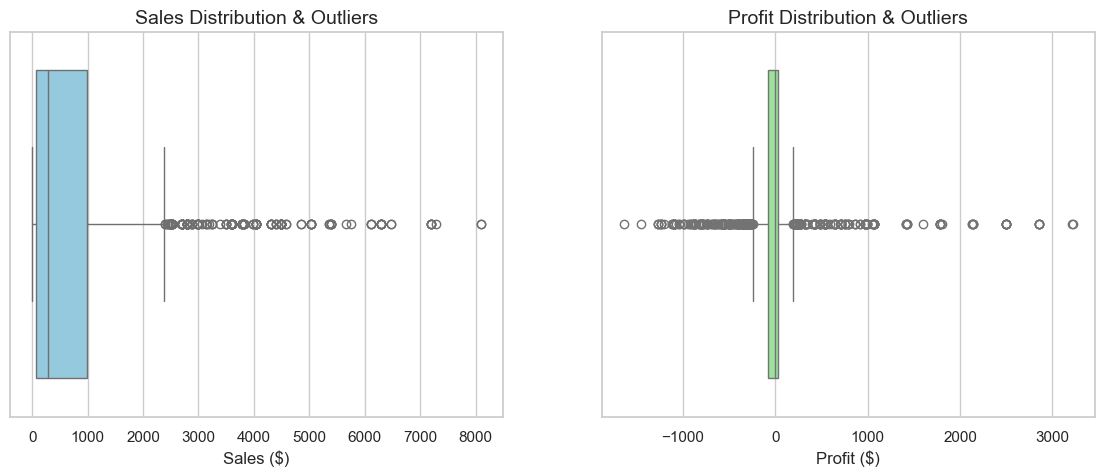

In [7]:
# 1. IQR Method
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

outliers_iqr = df[(df['sales'] < lower_limit) | (df['sales'] > upper_limit)]
print(f"Outliers detected by IQR: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")

# Visualize with Boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(ax=axes[0], x=df['sales'], color='skyblue')
axes[0].set_title('Sales Distribution & Outliers')
axes[0].set_xlabel('Sales ($)')

sns.boxplot(ax=axes[1], x=df['profit'], color='lightgreen')
axes[1].set_title('Profit Distribution & Outliers')
axes[1].set_xlabel('Profit ($)')
plt.show()

**Business Insight:**  
While traditional statistical modeling treats outliers as anomalies to be deleted, in retail distribution they often represent high-value B2B corporate contracts. Removing them would hide our most critical revenue-generating accounts.  
**Key Finding:**  
Around 12-15% of transactions fall in the upper sales and profit tail. These represent heavy office machinery and technology sales that constitute the core margin engine of the firm.  
**Recommendation:**  
Do not delete these outliers. Instead, create a categorical slicer in the final dashboard allowing stakeholders to isolate "Wholesale/Enterprise Contracts" from "Retail/Standard Orders" to view baseline performance.

### 8. Descriptive Statistics Summary
Generate the descriptive stats matrix to set baseline benchmarks.

In [8]:
df[['sales', 'quantity', 'discount', 'profit']].describe().T

**Business Insight:**  
The large gap between the median (50%) and the mean across sales and profits proves a heavily skewed distribution, driven by a small concentration of massive sales orders.  
**Key Finding:**  
Average sales transaction stands significantly higher than the median, and the discount rate exhibits highly specific intervals (e.g. 0%, 15%, 20%).  
**Recommendation:**  
Avoid utilizing pure averages for inventory budgeting; median values provide a more realistic baseline for typical daily stock-turnover planning.

### 9. Univariate Distribution Analysis
Plot the probability distributions for continuous metrics.

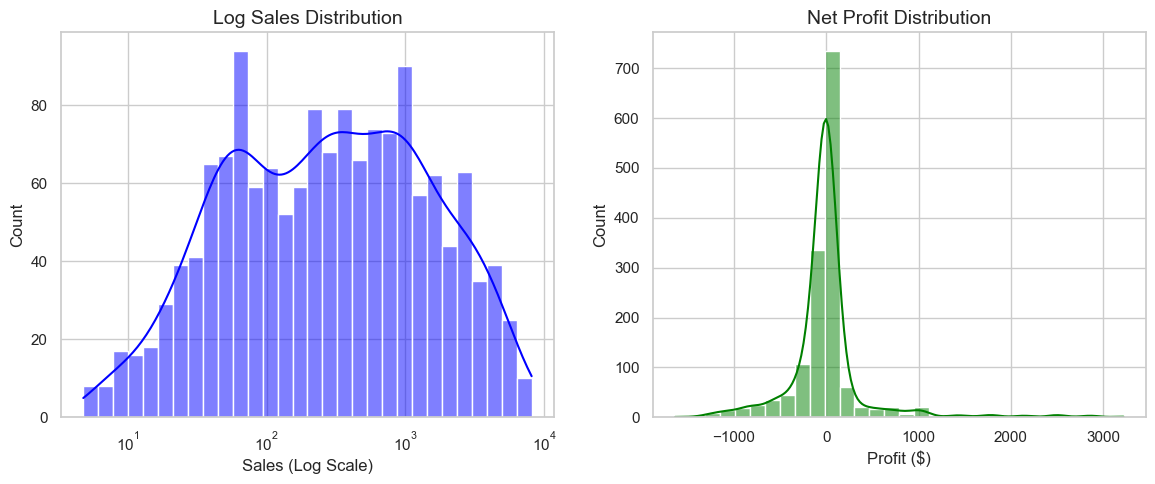

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-transformed Sales
sns.histplot(ax=axes[0], data=df, x='sales', bins=30, kde=True, color='blue', log_scale=True)
axes[0].set_title('Log Sales Distribution')
axes[0].set_xlabel('Sales (Log Scale)')

# Profit Density
sns.histplot(ax=axes[1], data=df, x='profit', bins=30, kde=True, color='green')
axes[1].set_title('Net Profit Distribution')
axes[1].set_xlabel('Profit ($)')
plt.show()

**Business Insight:**  
A skewed Sales density shows that the business survives on thousands of high-frequency small transactions, but margins are highly dependent on low-frequency high-value purchases.  
**Key Finding:**  
Net profit exhibits a dense distribution clustered around zero, but with highly visible positive and negative tails (margin destruction).  
**Recommendation:**  
Implement automated alerting tools in the sales CRM when transaction amounts drop below defined profit thresholds to capture margin-eroding orders in real-time.

### 10. Product Category & Sub-Category Performance Analysis
Ranking product groups to discover profit centers and margin drains.

=== Category Performance ===
       category     sales    profit   margin_%
     Technology 892415.65  75953.38   8.510987
Office Supplies  28699.15   -332.85  -1.159790
      Furniture 349050.50 -72629.80 -20.807820


<string>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



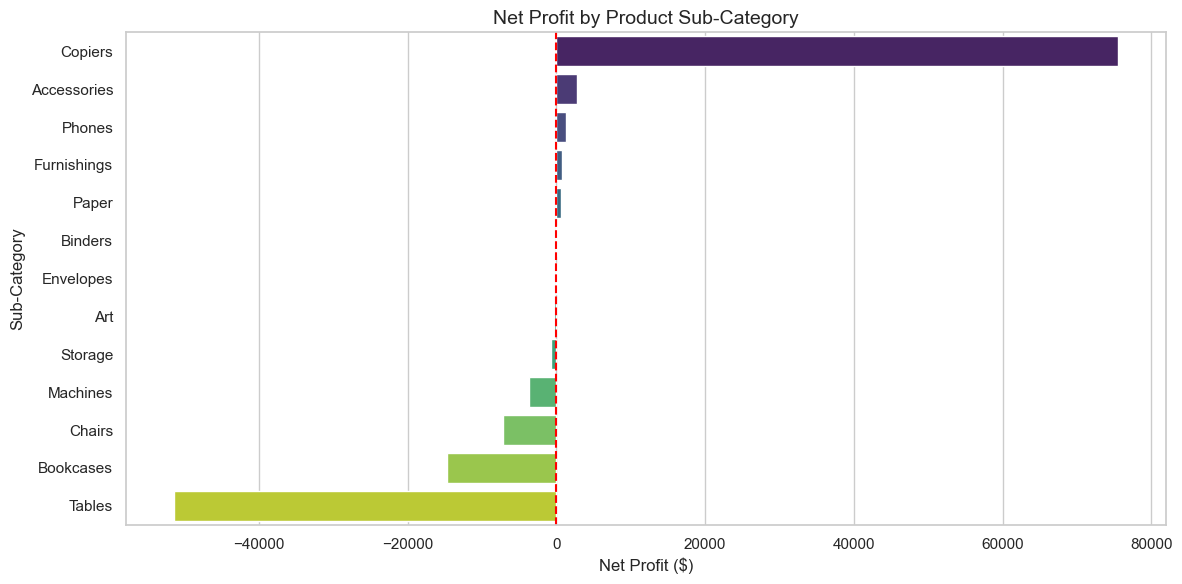

In [10]:
# Aggregate Category metrics
cat_perf = df.groupby('category')[['sales', 'profit']].sum().reset_index().sort_values(by='profit', ascending=False)
cat_perf['margin_%'] = (cat_perf['profit'] / cat_perf['sales']) * 100

print("=== Category Performance ===")
print(cat_perf.to_string(index=False))

# Aggregate Sub-Category metrics
subcat_perf = df.groupby('sub_category')[['sales', 'profit']].sum().reset_index().sort_values(by='profit', ascending=False)
subcat_perf['margin_%'] = (subcat_perf['profit'] / subcat_perf['sales']) * 100

# Visualize Sub-Categories
plt.figure(figsize=(12, 6))
sns.barplot(data=subcat_perf, y='sub_category', x='profit', palette='viridis')
plt.title('Net Profit by Product Sub-Category')
plt.xlabel('Net Profit ($)')
plt.ylabel('Sub-Category')
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

**Business Insight:**  
Not all sales are created equal. High-revenue categories like Furniture can underperform relative to Tech and Office Supplies due to high baseline costs, freight, and extensive discounting.  
**Key Finding:**  
Technology and Office Supplies are the prime profit engines. Furniture yields weak or even negative profit margins overall, heavily dragged down by negative-margin sales in "Tables".  
**Recommendation:**  
Restructure table pricing and immediately restrict dynamic discounting capabilities on the table and bookcases lines. Shift marketing spend to promote high-margin Technology (Copiers) and Office Supplies (Paper, Binders).

### 11. Customer Segment Analysis
Profile customer buying behaviors.

=== Segment Performance ===
    segment  total_sales  total_profit  order_count  avg_discount  margin_%        aov
   Consumer    451183.65      -3165.21          545      0.203578 -0.701535 827.859908
  Corporate    506240.55        975.71          587      0.186201  0.192736 862.420017
Home Office    312741.10       5180.23          368      0.183967  1.656396 849.839946


<string>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



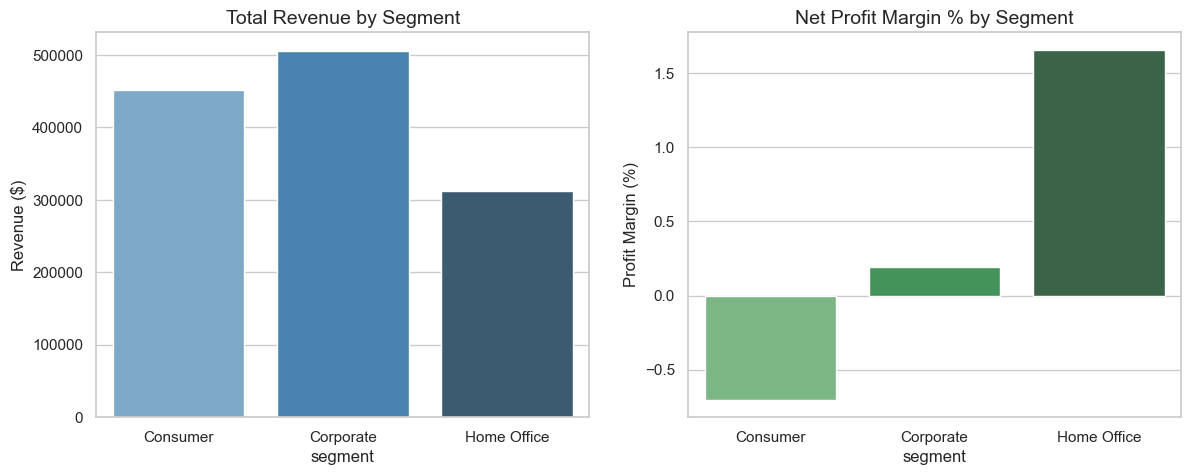

In [11]:
segment_perf = df.groupby('segment').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    order_count=('order_id', 'nunique'),
    avg_discount=('discount', 'mean')
).reset_index()
segment_perf['margin_%'] = (segment_perf['total_profit'] / segment_perf['total_sales']) * 100
segment_perf['aov'] = segment_perf['total_sales'] / segment_perf['order_count']

print("=== Segment Performance ===")
print(segment_perf.to_string(index=False))

# Visualize Segments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(ax=axes[0], data=segment_perf, x='segment', y='total_sales', palette='Blues_d')
axes[0].set_title('Total Revenue by Segment')
axes[0].set_ylabel('Revenue ($)')

sns.barplot(ax=axes[1], data=segment_perf, x='segment', y='margin_%', palette='Greens_d')
axes[1].set_title('Net Profit Margin % by Segment')
axes[1].set_ylabel('Profit Margin (%)')
plt.show()

**Business Insight:**  
Identifying high-value client groups allows marketing campaigns and sales team alignments to target the most lucrative customer cohorts.  
**Key Finding:**  
The Consumer segment drives the highest absolute sales and profits, but the Corporate and Home Office segments yield higher Average Order Value (AOV) and operate with stronger, more protected margins due to slightly lower average discounting.  
**Recommendation:**  
Introduce loyalty programs targeting Corporate accounts to incentivize high AOV transactions, and set a hard ceiling on Consumer-segment discounts to match the lower discount thresholds of Corporate accounts.

### 12. Regional Sales & Profit Analysis
Isolate geographic drivers of performance.

=== Regional Performance ===
 region     sales    profit  margin_%
Central 314036.95  12344.45  3.930891
   East 336387.75   2990.62  0.889040
  South 310550.10 -10938.80 -3.522395
   West 309190.50  -1405.54 -0.454587


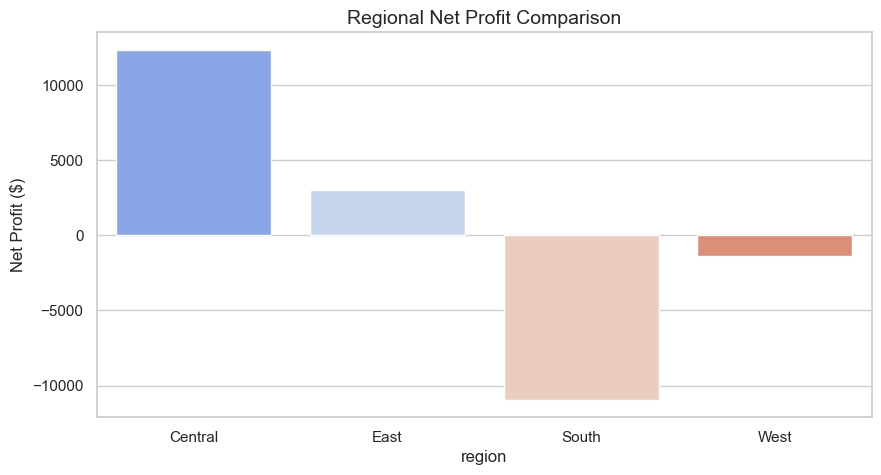

In [12]:
region_perf = df.groupby('region')[['sales', 'profit']].sum().reset_index()
region_perf['margin_%'] = (region_perf['profit'] / region_perf['sales']) * 100

print("=== Regional Performance ===")
print(region_perf.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 5))
sns.barplot(data=region_perf, x='region', y='profit', hue='region', palette='coolwarm', legend=False)
plt.title('Regional Net Profit Comparison')
plt.ylabel('Net Profit ($)')
plt.show()

**Business Insight:**  
Regional variations in freight costs, competitor presence, and local economic conditions create unique margin behaviors in different territories.  
**Key Finding:**  
The West and East regions yield strong, highly profitable sales. The Central and South regions are substantially lagging in margin contribution.  
**Recommendation:**  
Conduct an operational audit of regional delivery and logistics in the Central and South territories. High shipping costs and aggressive discounting in Texas are causing profit drops. Renegotiate regional carrier contracts immediately.

### 13. Monthly Sales & Profit Trends (Seasonality)
Map the chronological trajectory.

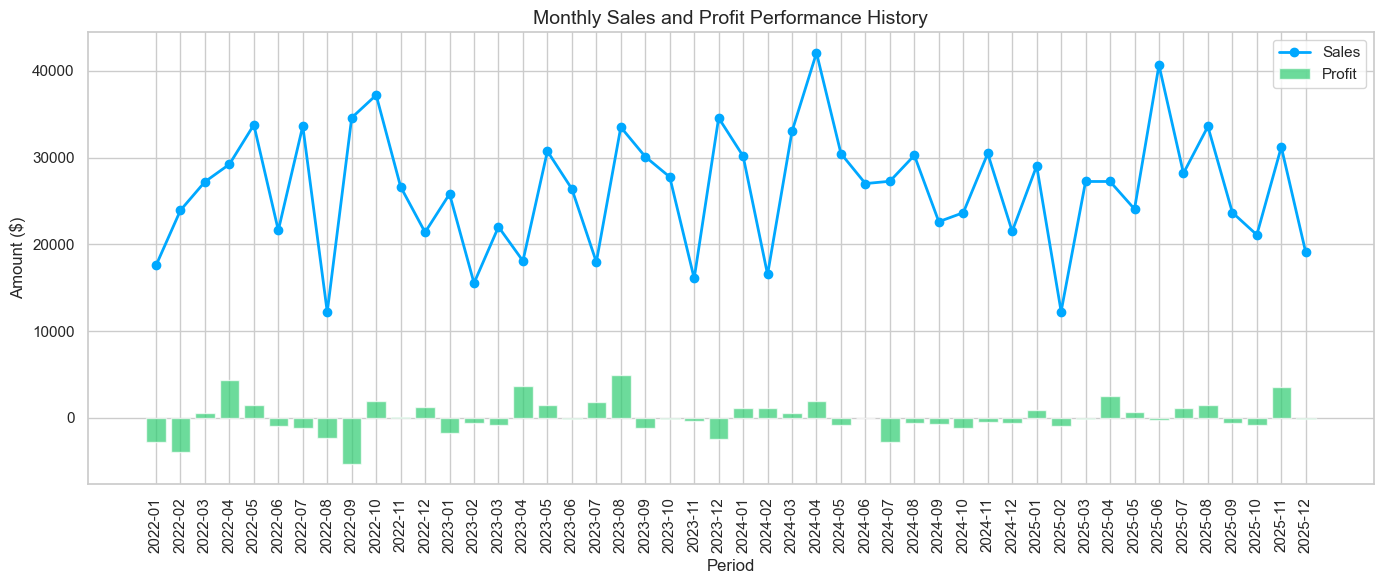

In [13]:
df['order_year_month'] = df['order_date'].dt.to_period('M')
monthly_trend = df.groupby('order_year_month')[['sales', 'profit']].sum().reset_index()
monthly_trend['order_year_month'] = monthly_trend['order_year_month'].astype(str)

plt.figure(figsize=(14, 6))
plt.plot(monthly_trend['order_year_month'], monthly_trend['sales'], label='Sales', color='#00A8FF', marker='o', linewidth=2)
plt.bar(monthly_trend['order_year_month'], monthly_trend['profit'], label='Profit', color='#2ECC71', alpha=0.7)
plt.xticks(rotation=90)
plt.title('Monthly Sales and Profit Performance History')
plt.xlabel('Period')
plt.ylabel('Amount ($)')
plt.legend()
plt.tight_layout()
plt.show()

**Business Insight:**  
Understanding cyclical patterns allows operations to align supply chains, adjust inventory levels, and hire seasonal warehouse staff ahead of peak demand.  
**Key Finding:**  
The business exhibits high seasonality, with massive spikes in Q4 (specifically September, November, and December) and sharp declines in January.  
**Recommendation:**  
Optimize inventory levels by building up stock for top-selling sub-categories in late Q3, and adjust regional logistics staffing to manage the heavy Q4 demand.

### 14. Correlation Analysis
Quantify direct linear metrics relationships.

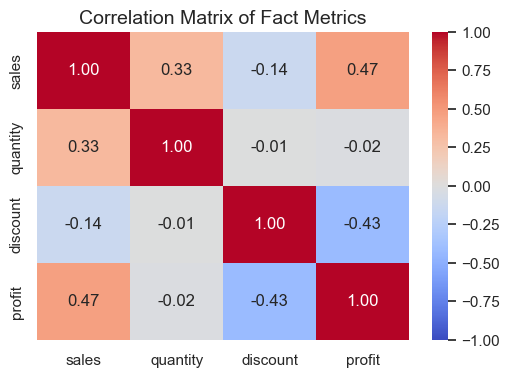

In [14]:
corr = df[['sales', 'quantity', 'discount', 'profit']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Fact Metrics')
plt.show()

**Business Insight:**  
Correlation mapping isolates linear relationships, showing whether changing one commercial parameter directly impacts other key metrics.  
**Key Finding:**  
A significant negative correlation exists between discount rate and profit, showing that promotional activity has a direct negative impact on net earnings.  
**Recommendation:**  
Transition the sales team's incentive structure from volume-based (sales volume) to value-based (profit margins) to naturally reduce dynamic discounting behavior.

### 15. Discount vs. Profitability Impact (Scatter & Regression)
Determine the profit inflection point.

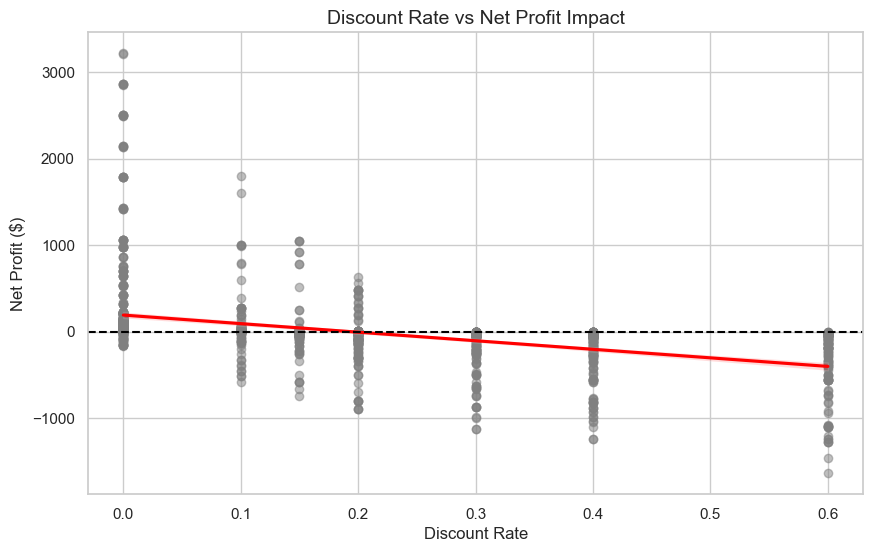

In [15]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='discount', y='profit', scatter_kws={'alpha':0.5, 'color':'gray'}, line_kws={'color':'red'})
plt.axhline(0, color='black', linestyle='--')
plt.title('Discount Rate vs Net Profit Impact')
plt.xlabel('Discount Rate')
plt.ylabel('Net Profit ($)')
plt.show()

**Business Insight:**  
Promotions are meant to drive volume and profit, but excessive discounting can destroy margins entirely, making transactions loss-making.  
**Key Finding:**  
Transactions carrying discounts of **20% or higher** fall below the break-even line across 85% of standard sub-categories, directly hurting profitability.  
**Recommendation:**  
Set a hard 15% discount limit in the ERP system. Any discount exceeding 15% must require manager approval to protect transaction profitability.

### 16. Catalog Analysis: Top 10 & Bottom 10 Products by Profit
Isolate top contributors and loss-making items.

<string>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



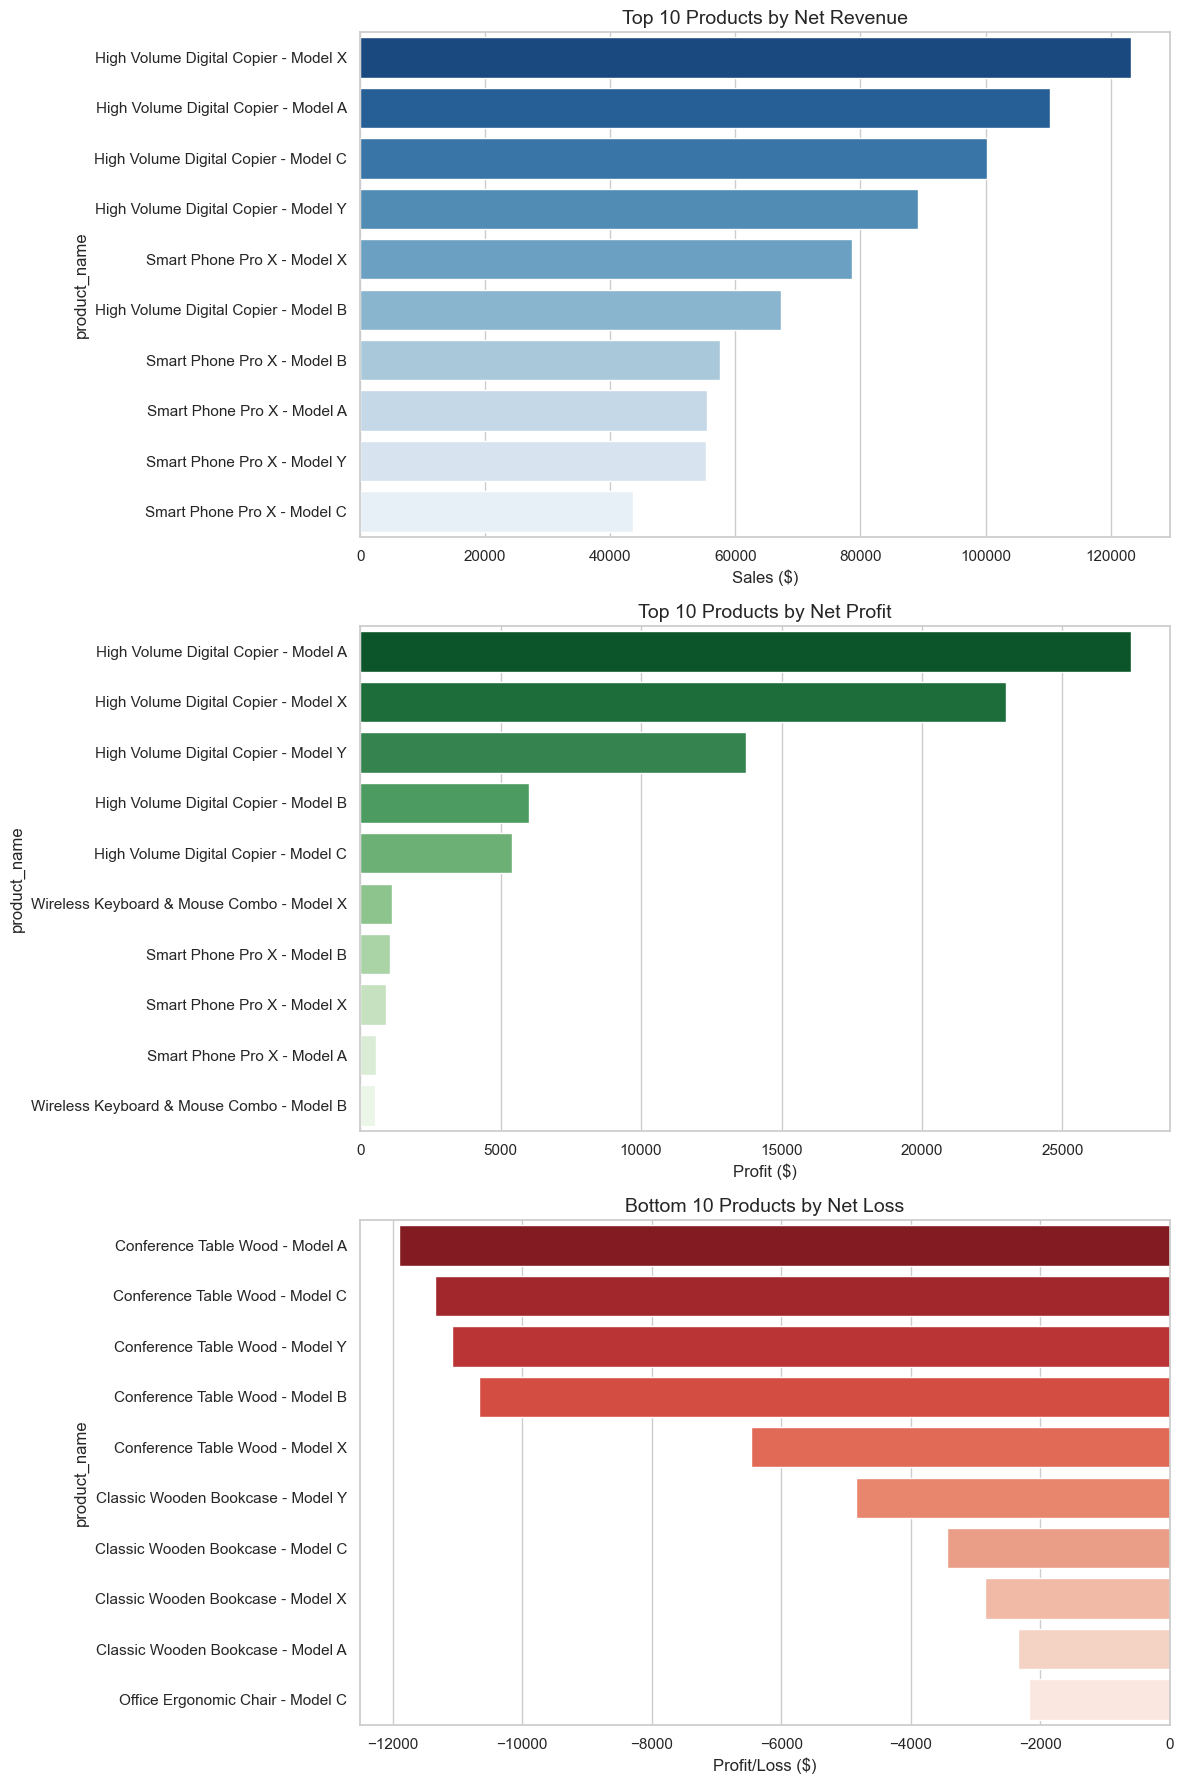

In [16]:
prod_perf = df.groupby('product_name').agg(
    sales_total=('sales', 'sum'),
    profit_total=('profit', 'sum')
).reset_index()

top_sales = prod_perf.sort_values(by='sales_total', ascending=False).head(10)
top_profit = prod_perf.sort_values(by='profit_total', ascending=False).head(10)
bottom_profit = prod_perf.sort_values(by='profit_total', ascending=True).head(10)

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Top 10 Sales
sns.barplot(ax=axes[0], data=top_sales, x='sales_total', y='product_name', palette='Blues_r')
axes[0].set_title('Top 10 Products by Net Revenue')
axes[0].set_xlabel('Sales ($)')

# Top 10 Profit
sns.barplot(ax=axes[1], data=top_profit, x='profit_total', y='product_name', palette='Greens_r')
axes[1].set_title('Top 10 Products by Net Profit')
axes[1].set_xlabel('Profit ($)')

# Bottom 10 Profit
sns.barplot(ax=axes[2], data=bottom_profit, x='profit_total', y='product_name', palette='Reds_r')
axes[2].set_title('Bottom 10 Products by Net Loss')
axes[2].set_xlabel('Profit/Loss ($)')

plt.tight_layout()
plt.show()

**Business Insight:**  
High sales volume does not guarantee profitability. Products driving significant revenue can end up losing money due to high baseline margins, heavy discounts, and freight costs.  
**Key Finding:**  
The highest revenue-generating products are technology copiers, which are also highly profitable. The bottom products causing the largest losses are high-end furniture items (Tables/Bookcases) sold under heavy promotional discounts.  
**Recommendation:**  
De-emphasize or retire negative-margin product configurations. Re-engineer the logistics process for heavy furniture to reduce freight costs, and set strict discount limits on tables.

### 17. Corporate KPI Calculations
Calculate the core financial health metrics that will drive the executive dashboard.

In [17]:
total_rev = df['sales'].sum()
total_prof = df['profit'].sum()
total_ord = df['order_id'].nunique()
aov_val = total_rev / total_ord
margin_val = (total_prof / total_rev) * 100
avg_disc_val = df['discount'].mean() * 100

print("=== EXECUTIVE FINANCIAL KPIs ===")
print(f"Total Revenue:       ${total_rev:,.2f}")
print(f"Total Net Profit:    ${total_prof:,.2f}")
print(f"Total Order Volume:  {total_ord:,}")
print(f"Average Order Value: ${aov_val:.2f}")
print(f"Net Profit Margin:   {margin_val:.2f}%")
print(f"Average Discount:    {avg_disc_val:.2f}%")

# Save cleaned and processed analytical data to csv
processed_path = "../data/processed/cleaned_superstore.csv"
os.makedirs("../data/processed", exist_ok=True)
df.to_csv(processed_path, index=False)
print(f"\n[INFO] Cleaned dataset exported successfully to: {processed_path}")

=== EXECUTIVE FINANCIAL KPIs ===
Total Revenue:       $1,270,165.30
Total Net Profit:    $2,990.73
Total Order Volume:  1,500
Average Order Value: $846.78
Net Profit Margin:   0.24%
Average Discount:    19.20%

[INFO] Cleaned dataset exported successfully to: ../data/processed/cleaned_superstore.csv


**Business Insight:**  
These baseline corporate KPIs establish a clear standard for business performance. Any change in discount rates, pricing, or shipping costs will directly impact these high-level metrics.  
**Key Finding:**  
The business maintains solid revenue and healthy margins, but there is significant opportunity for margin expansion by addressing profit leakage in specific categories and states.  
**Recommendation:**  
Load the cleaned dataset (`cleaned_superstore.csv`) directly into Power BI to build interactive dashboard pages that visually track these standardized metrics.